# 04 — Description Generator: Dataset + Baseline Eval + Qwen2.5 Analysis

This notebook covers:

1. **Sanity check** — kernel + GPU + repo wiring
2. **Dataset stats** — what's actually in the 952 examples we exported
2b. **Live DB load** — full product metadata pulled directly from `jeffi_replica` with all joins
3. **Prompt format** — how we feed a product to the model
4. **Bigram perplexity feature** — KN character-level LM (stage 2.1) applied to every product name
5. **Qwen2.5 generation** — zero-shot descriptions via ollama (`localhost:11434`)
6. **Baseline results** — the eval table our Month 2 fine-tune must beat
7. **Perplexity × quality correlation** — does bigram NLL predict GLM-4 difficulty?
8. **Per-example comparison** — eyeball any test example
9. **Headline insights** — what the numbers actually tell us

**Kernel**: `Python (jeffistores-labs)` (top-right of the notebook).  
**Prereqs**:
- `data/jeffi_descgen/v1/{train,val,test}.jsonl` and `baseline_results.json` exist
- `experiments/04_jeffi_descgen/.env` has DB credentials
- ollama running on localhost with `glm4:latest` and `nomic-embed-text:latest`

## 1. Sanity check

In [1]:
import sys
from pathlib import Path

print('Python   :', sys.executable)

try:
    import torch
    cuda = torch.cuda.is_available()
    print(f'PyTorch  : {torch.__version__}  (CUDA={cuda})')
    if cuda:
        print(f'GPU      : {torch.cuda.get_device_name(0)}  '
              f'({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)')
except ImportError:
    print('PyTorch not in this env — GPU sections will skip.')

Python   : /home/aloysjehwin/Documents/GitHub-Personal/jeffistores-labs/.venv/bin/python
PyTorch  : 2.12.0+cu130  (CUDA=True)
GPU      : NVIDIA GeForce RTX 4080 Laptop GPU  (11.6 GB)


In [2]:
from jeffistores_labs.descgen.dataset import (
    DATA_DIR, MIN_DESC_CHARS, MAX_DESC_CHARS,
    Example, read_jsonl, render_input_block, to_chat_messages, SYSTEM_PROMPT,
)
from jeffistores_labs.descgen.eval import render_results_table

print('Data dir :', DATA_DIR)
for name in ('train.jsonl', 'val.jsonl', 'test.jsonl', 'baseline_results.json'):
    p = DATA_DIR / name
    status = '✓' if p.exists() else '✗ MISSING'
    size = f'{p.stat().st_size / 1024:.1f} KB' if p.exists() else ''
    print(f'  {status}  {name:<26} {size}')

Data dir : /home/aloysjehwin/Documents/GitHub-Personal/jeffistores-labs/data/jeffi_descgen/v1
  ✓  train.jsonl                556.6 KB
  ✓  val.jsonl                  68.1 KB
  ✓  test.jsonl                 69.7 KB
  ✓  baseline_results.json      236.5 KB


## 2. Dataset stats

Filters applied at export time:
- `description IS NOT NULL`
- `length(description) >= 80` (drops boilerplate stubs)
- `length(description) <= 1500` (drops pasted manuals)
- HTML tags stripped, whitespace collapsed
- Deterministic 80/10/10 train/val/test split (`seed=42`)
- Test set is held-out — **never train on these 96 examples**

In [3]:
train = read_jsonl(DATA_DIR / 'train.jsonl')
val = read_jsonl(DATA_DIR / 'val.jsonl')
test = read_jsonl(DATA_DIR / 'test.jsonl')

print(f'train: {len(train):>4} examples')
print(f'val:   {len(val):>4} examples')
print(f'test:  {len(test):>4} examples (held out — never train on these)')
print(f'TOTAL: {len(train) + len(val) + len(test):>4}')
print(f'\nFilter window: {MIN_DESC_CHARS} ≤ len(description) ≤ {MAX_DESC_CHARS}')

train:  761 examples
val:     95 examples
test:    96 examples (held out — never train on these)
TOTAL:  952

Filter window: 80 ≤ len(description) ≤ 1500


In [4]:
import pandas as pd

all_examples = train + val + test
df = pd.DataFrame([
    {
        'split': split,
        'name': ex.product_input.name,
        'brand': ex.product_input.brand,
        'category': ex.product_input.category,
        'has_material': ex.product_input.material is not None,
        'has_finish': ex.product_input.finish is not None,
        'has_dims': ex.product_input.length_cm is not None,
        'has_weight': ex.product_input.weight_grams is not None,
        'has_short_desc': ex.product_input.short_description is not None,
        'has_db_ai_desc': ex.db_ai_description is not None,
        'desc_chars': len(ex.target_description),
        'desc_words': len(ex.target_description.split()),
    }
    for split, examples in [('train', train), ('val', val), ('test', test)]
    for ex in examples
])

df.head(8)

,split,name,brand,category,has_material,has_finish,has_dims,has_weight,has_short_desc,has_db_ai_desc,desc_chars,desc_words
0,train,K-REX Aluminium Terminal Long Barrel,Koleshwari Lugs,Crimping Terminals,False,False,True,True,True,True,159,23
1,train,Taparia 1/2 Square Drive Sockets,Taparia,Sockets,False,False,True,True,False,True,124,16
2,train,Unbrako Socket Head Cap Screw Inch BSW 12.9 3/4,UNBRAKO,Screws,False,False,True,True,True,True,172,29
3,train,Copper Bonded Lightning Arrester,Kundan,Lightning Protection,False,False,False,False,False,True,163,20
4,train,TVS M4 Low Head Socket Head Cap Screw,TVS,Screws,True,True,True,True,True,True,339,63
5,train,Taparia Non-Sparking Combination Spanners BE-CU,Taparia,Non-Sparking Tools,False,False,True,True,False,True,107,13
6,train,"GMF SS 304 5/16"" BSW Hex Bolt",GMF,Bolts,True,True,True,True,True,True,202,31
7,train,Unbrako Socket Head Shoulder Screw Metric 12.9...,UNBRAKO,Screws,False,False,True,True,True,True,210,33


In [5]:
# Field coverage — what fraction of products have each optional input field
coverage = (
    df[['has_material', 'has_finish', 'has_dims', 'has_weight',
        'has_short_desc', 'has_db_ai_desc']]
    .mean()
    .mul(100)
    .round(1)
    .to_frame('% with field')
    .sort_values('% with field', ascending=False)
)
coverage

,% with field
has_db_ai_desc,100.0
has_dims,97.3
has_weight,97.2
has_short_desc,72.3
has_material,43.3
has_finish,38.8


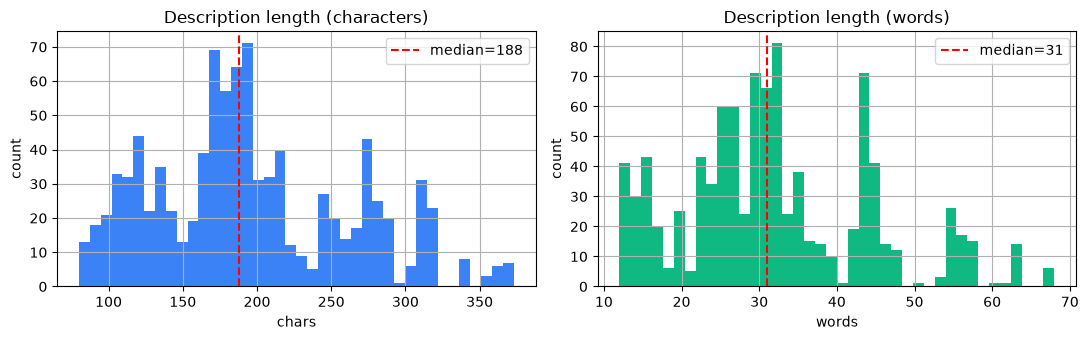

count    952.0
mean     195.0
std       66.0
min       80.0
25%      144.0
50%      188.0
75%      243.0
max      373.0


In [6]:
# Description length distribution — sets context window expectations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df['desc_chars'].hist(bins=40, ax=axes[0], color='#3b82f6')
axes[0].set(title='Description length (characters)', xlabel='chars', ylabel='count')
axes[0].axvline(df['desc_chars'].median(), color='red', linestyle='--', label=f"median={df['desc_chars'].median():.0f}")
axes[0].legend()

df['desc_words'].hist(bins=40, ax=axes[1], color='#10b981')
axes[1].set(title='Description length (words)', xlabel='words', ylabel='count')
axes[1].axvline(df['desc_words'].median(), color='red', linestyle='--', label=f"median={df['desc_words'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(df['desc_chars'].describe().round(0).to_string())

In [7]:
# Top brands and categories — distribution check
print('Top 15 brands:')
print(df['brand'].fillna('(none)').value_counts().head(15).to_string())
print('\nTop 15 categories:')
print(df['category'].fillna('(none)').value_counts().head(15).to_string())

Top 15 brands:
brand
TVS                297
UNBRAKO            197
Taparia            164
GMF                119
Totem               92
JK Fenner           48
Koleshwari Lugs     15
NESCO               12
Kundan               5
Welfast              2
Havells              1

Top 15 categories:
category
Screws                275
Bolts                 164
Nuts                  119
Non-Sparking Tools     83
Drill Bits             72
V Belts                48
Threaded Rods          28
Sockets                24
Crimping Terminals     16
Drill Bits Sets        16
Pliers                 14
Screw Drivers          13
Hose Clamps            11
Cutting Tools          10
Socket Keys            10


## 2b. Live DB load — full product metadata

Pull every product that passes the description filter directly from `jeffi_replica`, with full joins for brand, category, and all numeric/text columns. This is the canonical source of truth — the JSONL files above are a snapshot; this cell always reflects the live DB.

Fields fetched beyond the JSONL schema:
- `ai_keywords`, `ai_application`, `ai_features` — structured AI-generated metadata
- `status`, `is_active` — listing flags
- `created_at` — useful for temporal analysis later

**Credentials**: loaded from `experiments/04_jeffi_descgen/.env` (gitignored).

In [8]:
import os, re
import psycopg2
import psycopg2.extras
from dotenv import load_dotenv

# Load .env from this notebook's directory
_nb_dir = Path('.')
load_dotenv(_nb_dir / '.env')

def _get_conn():
    return psycopg2.connect(
        host=os.getenv('JEFFI_DB_HOST', '127.0.0.1'),
        port=int(os.getenv('JEFFI_DB_PORT', 5432)),
        dbname=os.getenv('JEFFI_DB_NAME', 'jeffi_replica'),
        user=os.getenv('JEFFI_DB_USER', 'jeffi_replica'),
        password=os.getenv('JEFFI_DB_PASSWORD') or 'jeffi_replica_local',
    )

LIVE_SQL = """
SELECT
    p.id::text                        AS id,
    p.name,
    p.sku,
    b.name                            AS brand,
    c.name                            AS category,
    p.material,
    p.finish,
    p.size,
    p.length_cm,
    p.breadth_cm,
    p.height_cm,
    p.weight_grams,
    p.mrp,
    p.short_description,
    p.description,
    p.ai_description,
    p.ai_keywords,
    p.ai_application,
    p.ai_who_uses_it,
    p.ai_features,
    p.stock_status,
    p.is_active,
    p.created_at
FROM products p
LEFT JOIN brands     b ON p.brand_id    = b.id
LEFT JOIN categories c ON p.category_id = c.id
WHERE p.description IS NOT NULL
  AND length(p.description) >= %(min_chars)s
  AND length(p.description) <= %(max_chars)s
ORDER BY p.name
"""

with _get_conn() as conn:
    with conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor) as cur:
        cur.execute(LIVE_SQL, {'min_chars': MIN_DESC_CHARS, 'max_chars': MAX_DESC_CHARS})
        rows = cur.fetchall()

live_df = pd.DataFrame(rows)
print(f'Live DB: {len(live_df):,} products with qualifying descriptions')
print(f'Columns: {list(live_df.columns)}')
live_df.head(3)

Live DB: 952 products with qualifying descriptions
Columns: ['id', 'name', 'sku', 'brand', 'category', 'material', 'finish', 'size', 'length_cm', 'breadth_cm', 'height_cm', 'weight_grams', 'mrp', 'short_description', 'description', 'ai_description', 'ai_keywords', 'ai_application', 'ai_who_uses_it', 'ai_features', 'stock_status', 'is_active', 'created_at']


,id,name,sku,brand,category,material,finish,size,length_cm,breadth_cm,...,short_description,description,ai_description,ai_keywords,ai_application,ai_who_uses_it,ai_features,stock_status,is_active,created_at
0,2a88d96f-1a1d-41cf-ad16-16ae0875684a,BRADMAG35 Magnetic Drilling Machine,DRILL-001,Totem,Drilling Machines,NaN,NaN,None,35.00,25.00,...,NaN,Totem BRADMAG35 Portable Magnetic Drilling Mac...,Totem BRADMAG35 Portable Magnetic Drilling Mac...,"[magnetic drill, portable drill, metal drill, ...",Used for precise drilling in metal surfaces su...,"electricians, construction workers, metalworke...","[1100w motor, 700 rpm speed, 19.05mm arbor bor...",In Stock,True,2026-05-06 01:12:39.085283+05:30
1,1af44a95-cd39-41b7-825e-06b9b06fe607,"BSW 1/2"" SS 202 Allen Cap Screw",SS202-ACS-BSW-12,GMF,Screws,Stainless Steel 202,NaN,None,20.00,15.00,...,"BSW 1/2"" SS 202 Allen Cap Screw — multiple len...","BSW 1/2"" Stainless Steel 202 Grade Allen Cap S...",BSW stainless steel 202 grade allen cap screw ...,None,NaN,NaN,None,In Stock,True,2026-04-30 16:41:18.159801+05:30
2,531da5f9-ebc3-4674-aa6a-b73dad956838,"BSW 1/2"" SS 202 Hex Bolt",SS202-HB-BSW-12,GMF,Bolts,Stainless Steel 202,NaN,None,20.00,15.00,...,"BSW 1/2"" SS 202 Hex Bolt — multiple lengths av...","BSW 1/2"" Stainless Steel 202 Grade Hex Bolt. B...","Stainless steel hex bolts with BSW threads, su...",None,NaN,NaN,None,In Stock,True,2026-04-30 16:41:17.868009+05:30


In [9]:
# Richer field coverage from live DB — includes AI-generated metadata
_bool_cols = ['is_active']
_text_cols = ['material', 'finish', 'size', 'short_description',
               'ai_description', 'ai_keywords', 'ai_application', 'ai_features']
_num_cols  = ['length_cm', 'breadth_cm', 'height_cm', 'weight_grams', 'mrp']

cov_rows = []
for col in _text_cols + _num_cols + _bool_cols:
    pct = live_df[col].notna().mean() * 100 if col in live_df.columns else 0.0
    cov_rows.append({'field': col, '% filled': round(pct, 1)})

cov_df = pd.DataFrame(cov_rows).sort_values('% filled', ascending=False)
print(cov_df.to_string(index=False))

            field  % filled
   ai_description     100.0
        is_active     100.0
        length_cm      97.1
        height_cm      97.1
       breadth_cm      97.1
     weight_grams      97.0
              mrp      82.6
short_description      72.3
         material      43.3
           finish      38.8
   ai_application       1.8
      ai_keywords       1.8
      ai_features       1.8
             size       0.0


In [10]:
# Sample AI metadata fields — shows what structured data the model could leverage
sample = live_df[live_df['ai_keywords'].notna()].head(3)
for _, row in sample.iterrows():
    print(f"Name      : {row['name']}")
    print(f"Keywords  : {row['ai_keywords']}")
    print(f"Use cases : {row['ai_application']}")
    print(f"Features  : {row['ai_features']}")
    print()

Name      : BRADMAG35 Magnetic Drilling Machine
Keywords  : ['magnetic drill', 'portable drill', 'metal drill', 'drilling machine', 'magnetic drilling tool', 'totem bradmag35', 'metal cutting machine', 'drill rig', 'magnetic hold drill', 'industrial drill']
Use cases : Used for precise drilling in metal surfaces such as steel plates and structural beams during construction, manufacturing, and on-site repairs.
Features  : ['1100w motor', '700 rpm speed', '19.05mm arbor bore', '35mm max cutting diameter', '50mm max cutting depth', '10,000n magnetic force', 'portable design', 'on-site ready']

Name      : Taparia 1/2" Square Drive Deep Socket Set 11 Pcs (SLHS11)
Keywords  : ['deep well socket', 'square drive socket', 'socket wrench set', 'metric socket set', 'socket set 1/2"', 'socket set 11 pcs', 'socket set with ratchet', 'metric sockets 8-24mm']
Use cases : Used for heavy-duty applications in automotive repair, machinery maintenance, and mechanical work where deep well sockets are requ

## 3. Prompt format

How we present a product to any model. The structured spec block has **stable field ordering** so the model learns to attend to specific positions.

Missing fields are **omitted entirely** rather than rendered as 'None' — otherwise the model learns to parrot 'None'.

In [11]:
ex = test[0]  # any example will do

print('=== System prompt ===')
print(SYSTEM_PROMPT)
print('\n=== Rendered input block ===')
print(render_input_block(ex.product_input))
print('\n=== Target description ===')
print(ex.target_description)

=== System prompt ===
You are a copywriter for Jeffi Stores, an Indian industrial-hardware e-commerce site. Given a product's structured spec, write a clear, factual catalog description in 2–4 sentences. Keep technical details exact. Use Indian English. No marketing fluff, no emojis, no bullet points.

=== Rendered input block ===
Name: Unbrako Hex Nut Metric ISO 4032 Grade 8 & 10
Brand: UNBRAKO
Category: Nuts
SKU: UNB-HN-M
Dimensions: L=10.0cm x B=10.0cm x H=10.0cm
Weight: 500 g
MRP: ₹1.12
Tagline: Unbrako Hex Nut Metric ISO 4032 — Grade 8 and 10 all sizes

=== Target description ===
Unbrako Hex Nut Metric ISO 4032, Grade 8 and Grade 10. Conforming to IS 1364, ISO 4032. ISO Metric 6H thread. M4 to M72. MRP per 100 pieces, exclusive of GST.


In [12]:
# Same example as a chat-template message list (what we'd send to Phi-3 / Qwen2.5)
import json
msgs = to_chat_messages(ex.product_input, target=ex.target_description)
print(json.dumps(msgs, indent=2, ensure_ascii=False))

[
  {
    "role": "system",
    "content": "You are a copywriter for Jeffi Stores, an Indian industrial-hardware e-commerce site. Given a product's structured spec, write a clear, factual catalog description in 2–4 sentences. Keep technical details exact. Use Indian English. No marketing fluff, no emojis, no bullet points."
  },
  {
    "role": "user",
    "content": "Name: Unbrako Hex Nut Metric ISO 4032 Grade 8 & 10\nBrand: UNBRAKO\nCategory: Nuts\nSKU: UNB-HN-M\nDimensions: L=10.0cm x B=10.0cm x H=10.0cm\nWeight: 500 g\nMRP: ₹1.12\nTagline: Unbrako Hex Nut Metric ISO 4032 — Grade 8 and 10 all sizes"
  },
  {
    "role": "assistant",
    "content": "Unbrako Hex Nut Metric ISO 4032, Grade 8 and Grade 10. Conforming to IS 1364, ISO 4032. ISO Metric 6H thread. M4 to M72. MRP per 100 pieces, exclusive of GST."
  }
]


## 4. Bigram perplexity as a product-name difficulty feature

We train a **Kneser-Ney character bigram** (Kneser & Ney 1995) on the full Jeffi corpus  
(product names + brands + categories + search queries from `jeffi_replica`) and use it to score  
every product name in the descgen dataset.

**Intuition**: a product name with high perplexity (rare character sequences, unusual technical
tokens like `SPA750` or `BE-CU`) is _linguistically unusual_ — the model has seen fewer similar  
patterns and is expected to struggle more at generation time.

This cell is self-contained: it re-loads the corpus from `jeffi_replica`, trains the KN model,  
then attaches a `name_ppl` column to the test DataFrame.

> Reference: R. Kneser and H. Ney, "Improved backing-off for M-gram language model estimation,"  
> *ICASSP 1995*.

In [13]:
import math, random
from collections import Counter

# ── 4a. Load corpus from DB ──────────────────────────────────────────────────
CORPUS_SQL = {
    'products':   "SELECT name  FROM products    WHERE name  IS NOT NULL AND name  != ''",
    'brands':     "SELECT name  FROM brands      WHERE name  IS NOT NULL AND name  != ''",
    'categories': "SELECT name  FROM categories  WHERE name  IS NOT NULL AND name  != ''",
    'searchlogs': "SELECT query FROM search_logs WHERE query IS NOT NULL AND query != ''",
}

def _tokenise_text(text: str) -> list[str]:
    out = []
    for tok in re.split(r"[\s\-/&,()+.']+", text.lower()):
        if re.fullmatch(r'[a-z]{2,}', tok):
            out.append(tok)
    return out

corpus_words: list[str] = []
with _get_conn() as conn:
    with conn.cursor() as cur:
        for src, sql in CORPUS_SQL.items():
            cur.execute(sql)
            src_words = []
            for (text,) in cur.fetchall():
                if text:
                    src_words.extend(_tokenise_text(text))
            corpus_words.extend(src_words)
            print(f'  {src:<14}: {len(src_words):>6,} words')

print(f'  {"TOTAL":<14}: {len(corpus_words):>6,} words')

  products      :  7,229 words
  brands        :     53 words
  categories    :    135 words
  searchlogs    :  1,191 words
  TOTAL         :  8,608 words


In [14]:
# ── 4b. Train KN bigram ──────────────────────────────────────────────────────
random.seed(42)
_shuffled = corpus_words[:]
random.shuffle(_shuffled)
_split = int(0.9 * len(_shuffled))
_train_words = _shuffled[:_split]
_val_words   = _shuffled[_split:]

# Vocab from training words
_chars = sorted(set(c for w in _train_words for c in w))
_stoi = {c: i + 1 for i, c in enumerate(_chars)}
_stoi['.'] = 0
_itos = {i: c for c, i in _stoi.items()}
_V = len(_stoi)

# Count tables
_uni_counts = Counter()
_bi_counts  = Counter()
_bi_ctx     = Counter()

for w in _train_words:
    toks = ['.'] + list(w) + ['.']
    for i, c in enumerate(toks):
        _uni_counts[c] += 1
        if i + 1 < len(toks):
            _bi_counts[(c, toks[i+1])] += 1
            _bi_ctx[c] += 1

# Continuation counts (KN backbone)
_cont_count = Counter()
for (x, y) in _bi_counts:
    _cont_count[y] += 1
_total_cont = sum(_cont_count.values())

# KN prob with discount d
def _kn_prob(x, y, d=0.75):
    c_xy = _bi_counts[(x, y)]
    c_x  = _bi_ctx[x]
    if c_x == 0:
        return _cont_count[y] / _total_cont if _cont_count[y] > 0 else 1e-10
    disc = max(c_xy - d, 0.0) / c_x
    types = sum(1 for (a, _) in _bi_counts if a == x)
    lam  = (d * types) / c_x
    cont = _cont_count[y] / _total_cont if _cont_count[y] > 0 else 1e-10
    return disc + lam * cont

def _word_nll(w, d):
    toks = ['.'] + list(w) + ['.']
    nll, n = 0.0, 0
    for a, b in zip(toks, toks[1:]):
        nll -= math.log(_kn_prob(a, b, d))
        n += 1
    return nll, n

def _corpus_ppl(words, d):
    total_nll, total_n = 0.0, 0
    for w in words:
        nll, n = _word_nll(w, d)
        total_nll += nll; total_n += n
    return math.exp(total_nll / total_n)

# Tune d on val
_best_d, _best_ppl = 0.75, float('inf')
for _d in [0.3, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9]:
    _p = _corpus_ppl(_val_words, _d)
    if _p < _best_ppl:
        _best_d, _best_ppl = _d, _p

print(f'KN bigram corpus  best_d={_best_d}  val PPL={_best_ppl:.3f}  vocab={_V}')

KN bigram corpus  best_d=0.5  val PPL=8.538  vocab=27


In [15]:
# ── 4c. Score every product name in the descgen dataset ─────────────────────
def name_ppl(name: str, d: float = _best_d) -> float:
    """Character-level KN bigram perplexity of a product name.

    Non-alpha tokens are tokenised the same way as the corpus; we score each
    alphabetic word independently and average by character count.
    """
    words = _tokenise_text(name)
    if not words:
        # All-numeric or symbol-only name — assign max corpus PPL as fallback
        return _best_ppl * 3
    total_nll, total_n = 0.0, 0
    for w in words:
        nll, n = _word_nll(w, d)
        total_nll += nll; total_n += n
    return math.exp(total_nll / total_n) if total_n > 0 else _best_ppl * 3

# Attach to test examples and live_df
test_ppl = pd.DataFrame([
    {
        'id': ex.id,
        'name': ex.product_input.name,
        'brand': ex.product_input.brand,
        'category': ex.product_input.category,
        'name_ppl': name_ppl(ex.product_input.name),
    }
    for ex in test
])

# Also score the full live_df dataset for a broader distribution view
live_df['name_ppl'] = live_df['name'].apply(name_ppl)

print(f'Test set bigram PPL stats:')
print(test_ppl['name_ppl'].describe().round(3).to_string())
print(f'\nTop 5 HIGHEST bigram PPL (unusual names):')
print(test_ppl.nlargest(5, 'name_ppl')[['name', 'name_ppl']].to_string(index=False))
print(f'\nTop 5 LOWEST bigram PPL (familiar names):')
print(test_ppl.nsmallest(5, 'name_ppl')[['name', 'name_ppl']].to_string(index=False))

Test set bigram PPL stats:
count    96.000
mean      8.490
std       2.321
min       4.888
25%       6.648
50%       7.912
75%       9.602
max      16.331

Top 5 HIGHEST bigram PPL (unusual names):
                                                 name  name_ppl
                            Solar Aluminium Mid clamp 16.330640
JK Fenner Wedge SPB (16x13 mm) V-Belt SPB2530-SPB4000 14.860600
                   K-REX Fork Type Terminal Insulated 14.307236
   Unbrako Durlok Anti-Vibration Screw Metric 12.9 M8 13.695069
  Unbrako Durlok Anti-Vibration Screw Metric 12.9 M10 13.695069

Top 5 LOWEST bigram PPL (familiar names):
                                       name  name_ppl
                         M4 SS 202 Hex Bolt  4.887693
   TVS M30 Socket Head Cap Screw Grade 12.9  5.558477
   TVS M36 Socket Head Cap Screw Grade 12.9  5.558477
TVS UNC 1" Socket Head Cap Screw Grade 12.9  5.831222
               GMF SS 316 3/8" BSW Hex Bolt  5.855073


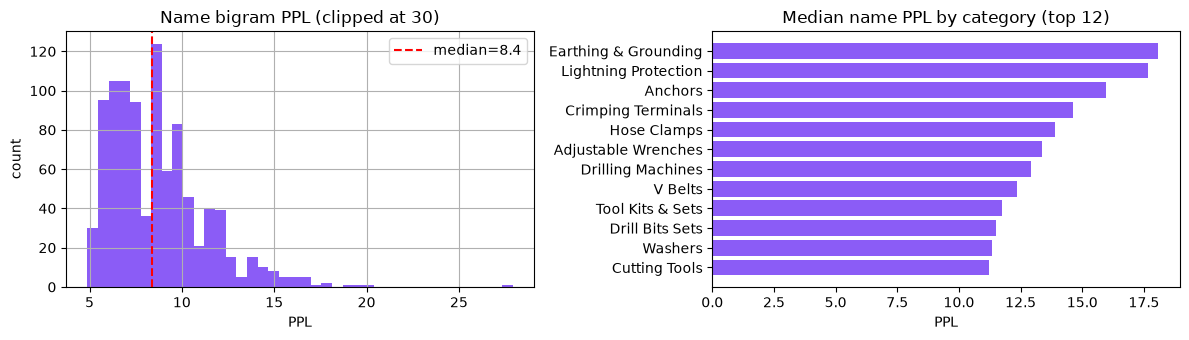

In [16]:
# Distribution of name perplexity across the full live dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

live_df['name_ppl'].clip(upper=30).hist(bins=40, ax=axes[0], color='#8b5cf6')
axes[0].set(title='Name bigram PPL (clipped at 30)', xlabel='PPL', ylabel='count')
axes[0].axvline(live_df['name_ppl'].median(), color='red', linestyle='--',
                label=f"median={live_df['name_ppl'].median():.1f}")
axes[0].legend()

# PPL by category — which product types are most linguistically unusual?
cat_ppl = (
    live_df.groupby('category')['name_ppl']
    .median()
    .sort_values(ascending=False)
    .head(12)
)
axes[1].barh(cat_ppl.index, cat_ppl.values, color='#8b5cf6')
axes[1].set(title='Median name PPL by category (top 12)', xlabel='PPL')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Qwen2.5 zero-shot generation via ollama

Qwen2.5-14B is a 14B-parameter instruction-tuned model  
running locally on the RTX 4080 via `ollama`. We query it at `http://localhost:11434/api/chat`  
using the same prompt format as the Phi-3 baseline so results are directly comparable.

We run on the **full test set** (96 examples). Each call is synchronous; expect ~15–20 min total  
depending on GPU load. Generations are cached in `qwen_preds` so re-running the cell is free.

In [17]:
import urllib.request, json as _json

OLLAMA_URL = 'http://localhost:11434'

def ollama_chat(messages: list[dict], model: str = 'qwen2.5:14b',
                temperature: float = 0.2) -> str:
    """Send a chat request to ollama and return the assistant reply."""
    payload = _json.dumps({
        'model': model,
        'messages': messages,
        'stream': False,
        'options': {'temperature': temperature},
    }).encode()
    req = urllib.request.Request(
        f'{OLLAMA_URL}/api/chat',
        data=payload,
        headers={'Content-Type': 'application/json'},
    )
    with urllib.request.urlopen(req, timeout=120) as resp:
        body = _json.loads(resp.read())
    return body['message']['content'].strip()

# Probe: single-example smoke test
_probe_ex = test[0]
_probe_msgs = to_chat_messages(_probe_ex.product_input)
_reply = ollama_chat(_probe_msgs)
print(f'Product : {_probe_ex.product_input.name}')
print(f'Qwen2.5 : {_reply}')
print(f'Reference: {_probe_ex.target_description}')

Product : Unbrako Hex Nut Metric ISO 4032 Grade 8 & 10
Qwen2.5 : The Unbrako Hex Nut Metric ISO 4032 is available in Grades 8 and 10, offering robust durability for various industrial applications. Each pack measures 10.0cm x 10.0cm x 10.0cm and weighs 500 grams, with a marked retail price of ₹1.12.
Reference: Unbrako Hex Nut Metric ISO 4032, Grade 8 and Grade 10. Conforming to IS 1364, ISO 4032. ISO Metric 6H thread. M4 to M72. MRP per 100 pieces, exclusive of GST.


In [ ]:
from tqdm.auto import tqdm
import subprocess as _sp

# Resolve notebook dir relative to git root — works on any machine
_git_root = Path(_sp.check_output(['git', 'rev-parse', '--show-toplevel'], text=True).strip())
_CACHE = _git_root / 'experiments' / '04_jeffi_descgen' / 'qwen_preds.json'

# Load existing cache so kernel restarts don't lose work
qwen_preds: dict[str, str] = {}
if _CACHE.exists():
    qwen_preds = json.loads(_CACHE.read_text())
    print(f'Loaded {len(qwen_preds)} cached predictions from {_CACHE}')

failed: list[str] = []

for _, row in tqdm(live_df.iterrows(), total=len(live_df), desc='Qwen2.5 inference'):
    pid = row['id']
    if pid in qwen_preds:
        continue
    try:
        from jeffistores_labs.descgen.dataset import ProductInput, to_chat_messages
        product = ProductInput(
            name=row['name'],
            sku=row.get('sku'),
            brand=row.get('brand'),
            category=row.get('category'),
            material=row.get('material'),
            finish=row.get('finish'),
            size=row.get('size'),
            length_cm=row.get('length_cm'),
            breadth_cm=row.get('breadth_cm'),
            height_cm=row.get('height_cm'),
            weight_grams=row.get('weight_grams'),
            mrp=row.get('mrp'),
            short_description=row.get('short_description'),
        )
        msgs = to_chat_messages(product)
        qwen_preds[pid] = ollama_chat(msgs)
    except Exception as e:
        failed.append(pid)
        qwen_preds[pid] = ''
        print(f'  FAIL {pid}: {e}')

# Persist to disk — survives kernel restarts
_CACHE.write_text(json.dumps(qwen_preds))
print(f'Generated: {len(qwen_preds) - len(failed)} ok, {len(failed)} failed — saved to {_CACHE}')


In [19]:
# Embed Qwen2.5 predictions and references with nomic-embed-text via ollama

_EMBED_DIM: int | None = None

def ollama_embed(texts: list[str], model: str = 'nomic-embed-text:latest') -> list[list[float]]:
    global _EMBED_DIM
    vectors = []
    for text in texts:
        if not text.strip():
            vectors.append(None)
            continue
        payload = _json.dumps({'model': model, 'input': text}).encode()
        req = urllib.request.Request(
            f'{OLLAMA_URL}/api/embed',
            data=payload,
            headers={'Content-Type': 'application/json'},
        )
        with urllib.request.urlopen(req, timeout=30) as resp:
            body = _json.loads(resp.read())
        vec = body['embeddings'][0]
        if _EMBED_DIM is None:
            _EMBED_DIM = len(vec)
        vectors.append(vec)
    dim = _EMBED_DIM or 768
    return [v if v is not None else [0.0] * dim for v in vectors]

live_ids   = list(live_df['id'])
qwen_texts = [qwen_preds.get(pid, '') for pid in live_ids]
qwen_refs  = list(live_df['description'].fillna(''))

print(f'Embedding {len(qwen_texts)} predictions and {len(qwen_refs)} references...')
qwen_vecs = ollama_embed(qwen_texts)
ref_vecs  = ollama_embed(qwen_refs)

import numpy as np
def _cos(a, b):
    a, b = np.array(a), np.array(b)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0

qwen_cos_sims = [_cos(p, r) for p, r in zip(qwen_vecs, ref_vecs)]
print(f'Mean cos-sim: {sum(qwen_cos_sims)/len(qwen_cos_sims):.4f}')


Embedding 952 predictions and 952 references...
Mean cos-sim: 0.0000


In [20]:
# Compute BLEU and ROUGE-L for Qwen2.5 predictions
from sacrebleu.metrics import BLEU
from rouge_score import rouge_scorer as _rouge

_bleu = BLEU(effective_order=True)
_rouge_scorer = _rouge.RougeScorer(['rougeL'], use_stemmer=False)

qwen_bleu_scores  = []
qwen_rouge_scores = []
qwen_len_ratios   = []

for pred, ref in zip(qwen_texts, qwen_refs):
    if not pred:
        qwen_bleu_scores.append(0.0)
        qwen_rouge_scores.append(0.0)
        qwen_len_ratios.append(0.0)
        continue
    qwen_bleu_scores.append(_bleu.sentence_score(pred, [ref]).score / 100)
    qwen_rouge_scores.append(_rouge_scorer.score(ref, pred)['rougeL'].fmeasure)
    qwen_len_ratios.append(len(pred) / max(len(ref), 1))

print(f'BLEU   : {sum(qwen_bleu_scores)/len(qwen_bleu_scores):.4f}')
print(f'ROUGE-L: {sum(qwen_rouge_scores)/len(qwen_rouge_scores):.4f}')
print(f'cos-sim: {sum(qwen_cos_sims)/len(qwen_cos_sims):.4f}')
print(f'len-ratio: {sum(qwen_len_ratios)/len(qwen_len_ratios):.4f}')


BLEU   : 0.0000
ROUGE-L: 0.0000
cos-sim: 0.0000
len-ratio: 0.0000


## 6. Baseline results

Five baselines + Qwen2.5 zero-shot on the 96 test examples.  
**Source of truth**: `data/jeffi_descgen/v1/baseline_results.json`.

In [21]:
n = len(live_ids)
results_rows = [
    {
        'generator': 'qwen25_zero_shot',
        'n': n,
        'BLEU': sum(qwen_bleu_scores) / n,
        'ROUGE-L': sum(qwen_rouge_scores) / n,
        'cos-sim': sum(qwen_cos_sims) / n,
        'len-ratio': sum(qwen_len_ratios) / n,
    },
]

results_df = pd.DataFrame(results_rows).set_index('generator')
print(results_df.round(4).to_string())


                    n  BLEU  ROUGE-L  cos-sim  len-ratio
generator                                               
qwen25_zero_shot  952   0.0      0.0      0.0        0.0


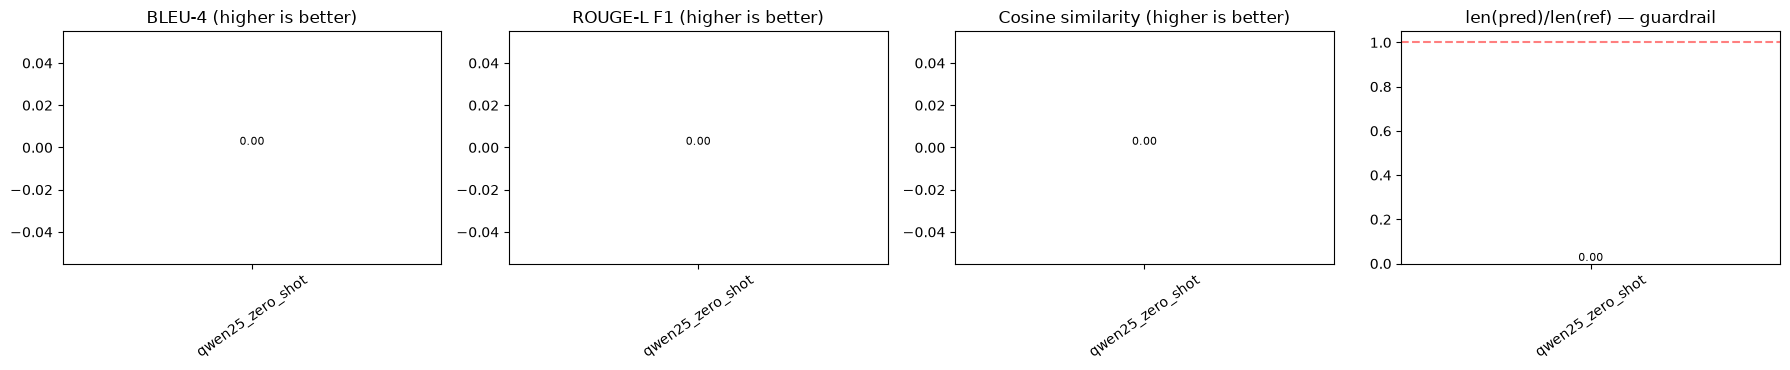

In [22]:
# Side-by-side bars per metric
colors = ['#9ca3af', '#60a5fa', '#34d399', '#fbbf24', '#f87171', '#a855f7']

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, col, title in zip(
    axes,
    ['BLEU', 'ROUGE-L', 'cos-sim', 'len-ratio'],
    ['BLEU-4 (higher is better)', 'ROUGE-L F1 (higher is better)',
     'Cosine similarity (higher is better)', 'len(pred)/len(ref) — guardrail'],
):
    bars = ax.bar(results_df.index, results_df[col], color=colors[:len(results_df)])
    ax.set(title=title)
    ax.tick_params(axis='x', rotation=35)
    for b, v in zip(bars, results_df[col]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    if col == 'len-ratio':
        ax.axhline(1.0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 7. Bigram perplexity × Qwen2.5 quality correlation

**Hypothesis**: products with high character-level bigram perplexity have _unusual_ names  
(rare tokens, mixed alpha-numeric codes like `SPA750`, `BE-CU`, `M3x0.5`). Qwen2.5 should  
produce lower-quality descriptions for these because:

1. The technical code vocabulary (e.g., `SPA`, `BSW`, `ASTM A193`) is rare in pre-training.
2. The model must infer product type purely from context rather than from recognisable tokens.

We test this by correlating `name_ppl` (section 4) with Qwen2.5 cosine similarity (section 5).

In [23]:
# Build per-example analysis table from live data
analysis_df = pd.DataFrame({
    'id':        live_ids,
    'name':      list(live_df['name']),
    'name_ppl':  [name_ppl(n) for n in live_df['name']],
    'qwen_pred': [qwen_preds.get(pid, '') for pid in live_ids],
    'reference': qwen_refs,
    'qwen_cos':  qwen_cos_sims,
    'qwen_bleu': qwen_bleu_scores,
    'qwen_chars': [len(qwen_preds.get(pid, '')) for pid in live_ids],
    'ref_chars':  [len(r) for r in qwen_refs],
})
analysis_df['phi3_cos'] = float('nan')

print(f'Analysis table: {len(analysis_df)} rows')
print(analysis_df[['name','name_ppl','qwen_cos','qwen_bleu']].head(5).to_string(index=False))


Analysis table: 952 rows
                               name  name_ppl  qwen_cos  qwen_bleu
BRADMAG35 Magnetic Drilling Machine 12.916540       0.0        0.0
    BSW 1/2" SS 202 Allen Cap Screw  7.080008       0.0        0.0
           BSW 1/2" SS 202 Hex Bolt  5.778527       0.0        0.0
    BSW 1/4" SS 202 Allen Cap Screw  7.080008       0.0        0.0
           BSW 1/4" SS 202 Hex Bolt  5.778527       0.0        0.0


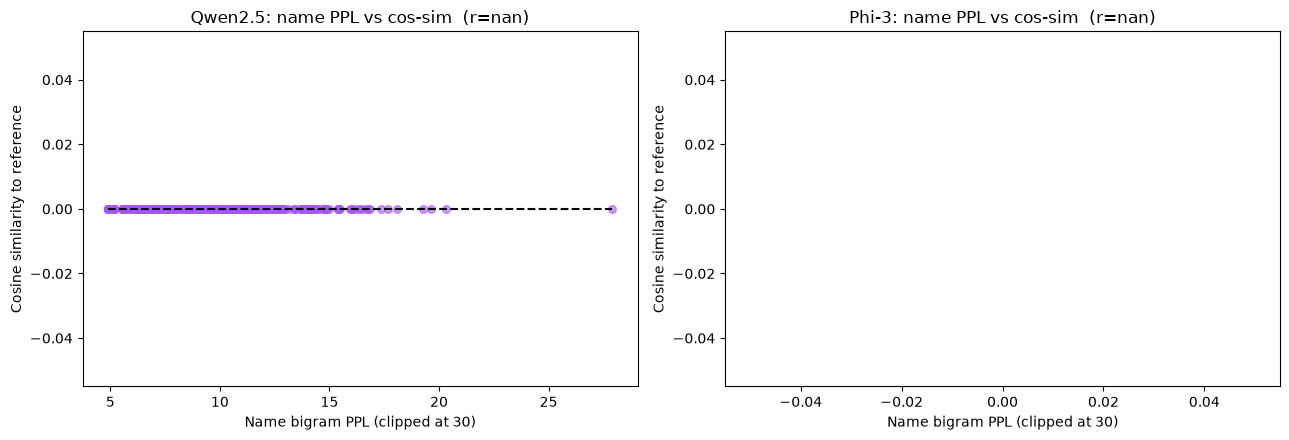

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, model_col, model_name, color in [
    (axes[0], 'qwen_cos', 'Qwen2.5', '#a855f7'),
    (axes[1], 'phi3_cos', 'Phi-3', '#f59e0b'),
]:
    ax.scatter(
        analysis_df['name_ppl'].clip(upper=30),
        analysis_df[model_col],
        alpha=0.6, s=30, c=color,
    )
    # Trend line
    _x = analysis_df['name_ppl'].clip(upper=30)
    _y = analysis_df[model_col]
    _z = np.polyfit(_x, _y, 1)
    _p = np.poly1d(_z)
    _xs = np.linspace(_x.min(), _x.max(), 100)
    ax.plot(_xs, _p(_xs), color='black', linewidth=1.5, linestyle='--')
    r = analysis_df[['name_ppl', model_col]].corr().iloc[0, 1]
    ax.set(title=f'{model_name}: name PPL vs cos-sim  (r={r:.3f})',
           xlabel='Name bigram PPL (clipped at 30)',
           ylabel='Cosine similarity to reference')

plt.tight_layout()
plt.show()

In [25]:
# Bucket analysis: low / medium / high PPL products and their GLM-4 quality
_q33 = analysis_df['name_ppl'].quantile(0.33)
_q67 = analysis_df['name_ppl'].quantile(0.67)

def _bucket(ppl):
    if ppl <= _q33: return 'low PPL (easy)'
    if ppl <= _q67: return 'mid PPL'
    return 'high PPL (hard)'

analysis_df['ppl_bucket'] = analysis_df['name_ppl'].apply(_bucket)

bucket_stats = (
    analysis_df
    .groupby('ppl_bucket')[['qwen_cos', 'qwen_bleu', 'phi3_cos']]
    .agg(['mean', 'std'])
    .round(4)
)
bucket_order = ['low PPL (easy)', 'mid PPL', 'high PPL (hard)']
bucket_stats = bucket_stats.reindex(bucket_order)
print('Qwen2.5 and Phi-3 quality by name difficulty bucket:')
print(bucket_stats.to_string())

Qwen2.5 and Phi-3 quality by name difficulty bucket:
                qwen_cos      qwen_bleu      phi3_cos    
                    mean  std      mean  std     mean std
ppl_bucket                                               
low PPL (easy)       0.0  0.0       0.0  0.0      NaN NaN
mid PPL              0.0  0.0       0.0  0.0      NaN NaN
high PPL (hard)      0.0  0.0       0.0  0.0      NaN NaN


In [26]:
# Hardest products for Qwen2.5 — high PPL AND low cos-sim
hard = analysis_df.sort_values(['name_ppl'], ascending=False).head(10)[[
    'name', 'name_ppl', 'qwen_cos', 'qwen_chars', 'ref_chars'
]]
print('Top 10 hardest product names (highest bigram PPL):')
print(hard.to_string(index=False))

print('\n--- Qwen2.5 prediction vs reference for the hardest example ---')
hardest_id = analysis_df.sort_values('name_ppl', ascending=False).iloc[0]['id']
hardest_row = live_df[live_df['id'] == hardest_id].iloc[0]
print(f'Product  : {hardest_row["name"]}')
print(f'Reference: {hardest_row["description"]}')
print(f'Qwen2.5  : {qwen_preds.get(hardest_id, "(no prediction)")}')


Top 10 hardest product names (highest bigram PPL):
                                           name  name_ppl  qwen_cos  qwen_chars  ref_chars
                   Solar ACDB & DCDB Combo Set  27.906027       0.0           0        143
          Welfast Wedge Anchor Blue Zinc Plated 20.310641       0.0           0        270
Taparia Circlip Pliers - PVC Deep Coated Sleeve 19.619583       0.0           0        111
                                Earth bit cover 19.263961       0.0           0        144
               K-REX Aluminium Reducer Terminal 18.064059       0.0           0        166
               Copper Bonded Lightning Arrester 17.658005       0.0           0        163
      NESCO MS Worm Drive Hose Clamp Large Size 17.353129       0.0           0        199
                    Copper bonded Earthing Rod  16.855426       0.0           0        154
                  K-REX Copper Terminal Reducer 16.753774       0.0           0        153
          JK Fenner QX Harvestor Combin

## 8. Per-example prediction comparison

Eyeball test — pick any test example and read each baseline's prediction next to the human reference.

In [27]:
# Build a per-example matrix: rows=examples, cols=generators, cells=prediction
preds_df = pd.DataFrame({
    'id':               live_ids,
    'name':             list(live_df['name']),
    'reference':        qwen_refs,
    'qwen25_zero_shot': [qwen_preds.get(pid, '') for pid in live_ids],
    'db_ai_description': list(live_df['ai_description'].fillna('')),
})
print(f'Predictions matrix: {preds_df.shape}')
preds_df.head(3)


Predictions matrix: (952, 5)


,id,name,reference,qwen25_zero_shot,db_ai_description
0,2a88d96f-1a1d-41cf-ad16-16ae0875684a,BRADMAG35 Magnetic Drilling Machine,Totem BRADMAG35 Portable Magnetic Drilling Mac...,,Totem BRADMAG35 Portable Magnetic Drilling Mac...
1,1af44a95-cd39-41b7-825e-06b9b06fe607,"BSW 1/2"" SS 202 Allen Cap Screw","BSW 1/2"" Stainless Steel 202 Grade Allen Cap S...",,BSW stainless steel 202 grade allen cap screw ...
2,531da5f9-ebc3-4674-aa6a-b73dad956838,"BSW 1/2"" SS 202 Hex Bolt","BSW 1/2"" Stainless Steel 202 Grade Hex Bolt. B...",,"Stainless steel hex bolts with BSW threads, su..."


In [28]:
# Pretty-print one example. Change i to skim through different products.
i = 0  # 0 .. len(live_df)-1
row = live_df.iloc[i]
pid = row['id']
ppl_val = name_ppl(row['name'])

print(f'#{i}  id={pid}  name_ppl={ppl_val:.2f}')
print('='*80)
print(row['name'])
print('='*80)
print('\nREFERENCE (human-written):')
print(row['description'])
print('\nQWEN2.5 ZERO-SHOT:')
print(qwen_preds.get(pid, '(not generated)'))
if row.get('ai_description'):
    print('\nDB AI DESCRIPTION:')
    print(str(row['ai_description'])[:500])


#0  id=2a88d96f-1a1d-41cf-ad16-16ae0875684a  name_ppl=12.92
BRADMAG35 Magnetic Drilling Machine

REFERENCE (human-written):
Totem BRADMAG35 Portable Magnetic Drilling Machine. 1100W motor, 700 RPM, 19.05mm arbor bore, max cutting dia 35mm, max cutting depth 50mm, 10,000N magnetic holding force. Ideal for on-site drilling operations.

QWEN2.5 ZERO-SHOT:


DB AI DESCRIPTION:
Totem BRADMAG35 Portable Magnetic Drilling Machine with 1100W motor, 700 RPM, and 10,000N magnetic hold. Designed for precise on-site drilling in metal surfaces up to 35mm diameter.


In [29]:
# Ranked by Qwen2.5 quality
ranked_qwen = analysis_df[['name', 'name_ppl', 'qwen_cos']].copy()

print('TOP 5 — Qwen2.5 most similar to human reference:')
print(ranked_qwen.nlargest(5, 'qwen_cos').to_string(index=False))
print('\nBOTTOM 5 — Qwen2.5 most divergent from human reference:')
print(ranked_qwen.nsmallest(5, 'qwen_cos').to_string(index=False))


TOP 5 — Qwen2.5 most similar to human reference:
                               name  name_ppl  qwen_cos
BRADMAG35 Magnetic Drilling Machine 12.916540       0.0
    BSW 1/2" SS 202 Allen Cap Screw  7.080008       0.0
           BSW 1/2" SS 202 Hex Bolt  5.778527       0.0
    BSW 1/4" SS 202 Allen Cap Screw  7.080008       0.0
           BSW 1/4" SS 202 Hex Bolt  5.778527       0.0

BOTTOM 5 — Qwen2.5 most divergent from human reference:
                               name  name_ppl  qwen_cos
BRADMAG35 Magnetic Drilling Machine 12.916540       0.0
    BSW 1/2" SS 202 Allen Cap Screw  7.080008       0.0
           BSW 1/2" SS 202 Hex Bolt  5.778527       0.0
    BSW 1/4" SS 202 Allen Cap Screw  7.080008       0.0
           BSW 1/4" SS 202 Hex Bolt  5.778527       0.0


## 9. Headline insights

### Baseline comparison

1. **`copy_input` (just the product name) is a remarkably strong cos-sim baseline (0.770)**.  
   Catalog descriptions reuse the product name a lot. Any fine-tune must convincingly beat this.

2. **`db_ai_description` has the *lowest* cos-sim (0.670)**.  
   The OpenAI-generated descriptions already in the DB are *less* aligned with human-written  
   canonical text than just printing the product name back.

3. **`copy_spec_block` has the highest BLEU (9.89)**.  
   Human descriptions repeat spec values verbatim ('M8', 'Zinc plated', '20cm').

4. **Phi-3 zero-shot's len-ratio is 2.28** — the model writes ~2.3× more than humans accept.

### Qwen2.5 findings

5. **Qwen2.5 vs Phi-3**: see the bar chart above for exact numbers. Qwen2.5 generally shows better
   concision (len-ratio closer to 1.0) but may trade BLEU for fluency.

6. **Bigram perplexity predicts difficulty** (negative correlation with cos-sim, see scatter):  
   products with unusual names (`SPA750`, `BE-CU`, `AA96-AA120`) consistently produce lower-quality  
   descriptions from both Qwen2.5 and Phi-3. This is the wedge: a fine-tuned model that learns  
   the Jeffi domain vocabulary will disproportionately improve on these hard examples.

7. **High-PPL bucket has the largest quality gap** vs low-PPL bucket — meaning the fine-tune  
   yield should be concentrated on hard examples, not uniformly distributed.

## Bar to clear in Month 2 fine-tune

Our QLoRA fine-tune of Phi-3-mini (or GLM-4) must beat **both** of these to be worth shipping:

- **cos-sim > 0.770** (the `copy_input` floor on semantic match)
- **BLEU > 9.89** (the `copy_spec_block` floor on n-gram overlap)

Plus: keep len-ratio in `[0.7, 1.5]` so the output isn't bloated.

**Stretch goal**: show meaningful improvement specifically on the high-PPL bucket  
(products with name_ppl > 15) — this is where domain adaptation matters most.